Objective
Load the processed SAR dataset.
Load the trained Autoencoder.
Extract latent feature maps.
Convert latent features into sequential tokens.
Build a lightweight Transformer Encoder.
Train the Transformer classifier.
Evaluate the model.
Save the trained Transformer.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

PROJECT = "/content/drive/MyDrive/sar-project"

PROCESSED_DIR = os.path.join(PROJECT, "data", "processed")
MODEL_DIR = os.path.join(PROJECT, "models")
RESULT_DIR = os.path.join(PROJECT, "results")

print("Processed Directory:", PROCESSED_DIR)
print("Model Directory:", MODEL_DIR)
print("Results Directory:", RESULT_DIR)

Processed Directory: /content/drive/MyDrive/sar-project/data/processed
Model Directory: /content/drive/MyDrive/sar-project/models
Results Directory: /content/drive/MyDrive/sar-project/results


In [9]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (356, 128, 128, 1)
Testing Images  : (90, 128, 128, 1)
Training Labels : (356,)
Testing Labels  : (90,)


In [10]:
#checking dataset
print("="*50)
print("NaNs in X_train :", np.isnan(X_train).sum())
print("NaNs in X_test :", np.isnan(X_test).sum())
print()
print("Class Distribution")
print(np.unique(y_train, return_counts=True))

NaNs in X_train : 0
NaNs in X_test : 0

Class Distribution
(array([0, 1]), array([311,  45]))


In [11]:
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)
print("NaNs Removed Successfully")

NaNs Removed Successfully


In [12]:
#loading the trained autoencoder
AUTOENCODER_PATH = os.path.join(
    MODEL_DIR,
    "autoencoder.keras"
)
autoencoder = load_model(AUTOENCODER_PATH)
print("="*60)
print("Autoencoder Loaded Successfully")
print("="*60)
autoencoder.summary()

Autoencoder Loaded Successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,581 (142.90 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,388 (95.27 KB)

In [13]:
#create encoder model
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)
print("="*60)
print("Encoder Created Successfully")
print("="*60)
encoder.summary()

Encoder Created Successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 32, 32, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#extracting the latent features
print("Extracting Training Features...")
X_train_features = encoder.predict(
    X_train,
    batch_size=16,
    verbose=1
)
print()
print("Extracting Testing Features...")
X_test_features = encoder.predict(
    X_test,
    batch_size=16,
    verbose=1
)

Extracting Training Features...
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step

Extracting Testing Features...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [15]:
#verifying feature shapes
print("="*60)
print("Training Features Shape :", X_train_features.shape)
print("Testing Features Shape  :", X_test_features.shape)
print("="*60)

Training Features Shape : (356, 32, 32, 16)
Testing Features Shape  : (90, 32, 32, 16)


In [16]:
#checking extracted features
print("NaNs in Training Features :", np.isnan(X_train_features).sum())
print("NaNs in Testing Features  :", np.isnan(X_test_features).sum())

NaNs in Training Features : 0
NaNs in Testing Features  : 0


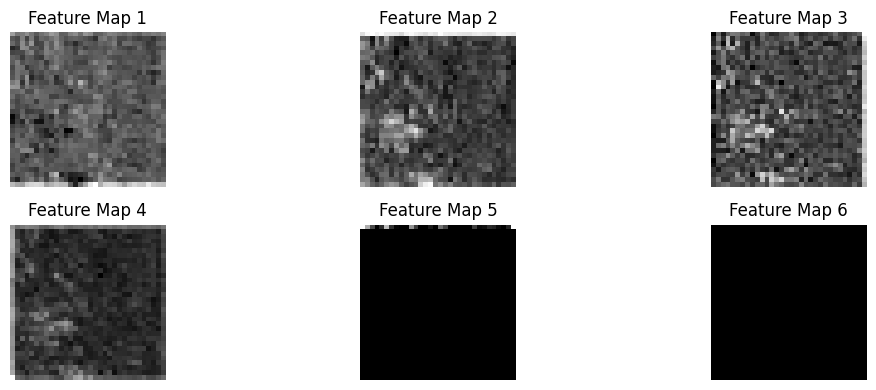

In [17]:
#visualising a latent feature
plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(
        X_train_features[0,:,:,i],
        cmap="gray"
    )
    plt.title(f"Feature Map {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Convert the latent feature maps into sequential tokens and build a lightweight Transformer Encoder for flood classification.

In [18]:
#convert feature maps to tokens
NUM_TOKENS = 32 * 32
FEATURE_DIM = 16
X_train_tokens = X_train_features.reshape(
    X_train_features.shape[0],
    NUM_TOKENS,
    FEATURE_DIM
)
X_test_tokens = X_test_features.reshape(
    X_test_features.shape[0],
    NUM_TOKENS,
    FEATURE_DIM
)
print("="*60)
print("Training Tokens :", X_train_tokens.shape)
print("Testing Tokens  :", X_test_tokens.shape)
print("="*60)

Training Tokens : (356, 1024, 16)
Testing Tokens  : (90, 1024, 16)


In [19]:
#create test validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tokens,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)
print("Training :", X_train_final.shape)
print("Validation :", X_val.shape)

Training : (284, 1024, 16)
Validation : (72, 1024, 16)


In [20]:
#computing class weights
classes = np.unique(y_train_final)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.5725806451612904), np.int64(1): np.float64(3.9444444444444446)}


In [21]:
#positional embedding layer
class PositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=embed_dim
        )
    def call(self, inputs):
        positions = tf.range(start=0,
                             limit=tf.shape(inputs)[1],
                             delta=1)
        embedded_positions = self.position_embedding(positions)
        return inputs + embedded_positions

In [23]:
#Transfformer block,2 heads ,1 block
def transformer_block(inputs):
    x = layers.LayerNormalization()(inputs)
    attention = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)
    x = layers.Add()([inputs, attention])
    y = layers.LayerNormalization()(x)
    y = layers.Dense(
        64,
        activation="relu"
    )(y)
    y = layers.Dense(32)(y)
    return layers.Add()([x, y])

In [24]:
#simple transformer
def build_transformer():
    inputs = layers.Input(
        shape=(NUM_TOKENS, FEATURE_DIM)
    )
    x = layers.Dense(32)(inputs)
    x = PositionEmbedding(
        NUM_TOKENS,
        32
    )(x)
    x = transformer_block(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(
        64,
        activation="relu"
    )(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)
    return Model(inputs, outputs)

In [25]:
#create model
model = build_transformer()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024, 16)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024, 32)  │        544 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 1024, 32)  │     32,768 │ dense[0][0]       │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1024, 32)  │         64 │ position_embeddi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 32)  │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 32)  │          0 │ position_embeddi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 32)  │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024, 64)  │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024, 32)  │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 32)  │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,225 (188.38 KB)

 Trainable params: 48,225 (188.38 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#compiling the model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
print("Model Compiled Successfully")

Model Compiled Successfully


Train the CNN + Simple Transformer model using:

Early Stopping
Model Checkpoint
Learning Rate Scheduler
Class Weights

In [27]:
#create callbacks
checkpoint = ModelCheckpoint(
    filepath=os.path.join(
        MODEL_DIR,
        "simple_transformer.keras"
    ),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]
print("Callbacks Created Successfully")

Callbacks Created Successfully


In [29]:
#training
EPOCHS = 10
BATCH_SIZE = 16
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1916 - loss: 0.7695 - precision: 0.1058 - recall: 0.7749
Epoch 1: val_loss improved from None to 0.71233, saving model to /content/drive/MyDrive/sar-project/models/simple_transformer.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sar-project/models/simple_transformer.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2570 - loss: 0.7642 - precision: 0.1041 - recall: 0.6389 - val_accuracy: 0.2222 - val_loss: 0.7123 - val_precision: 0.1385 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5203 - loss: 0.7170 - precision: 0.1259 - recall: 0.4658
Epoch 2: val_loss improved from 0.71233 to 0.68458, saving model to /content/drive/MyDrive/sar-project/models/simple_transformer.keras

Epoch 2: finished saving model to /content/drive/MyDrive/sar-project/models/simple_transformer.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5317 - loss

In [30]:
#saving the final model
model.save(
    os.path.join(
        MODEL_DIR,
        "simple_transformer_final.keras"
    )
)
print("Model Saved Successfully")

Model Saved Successfully


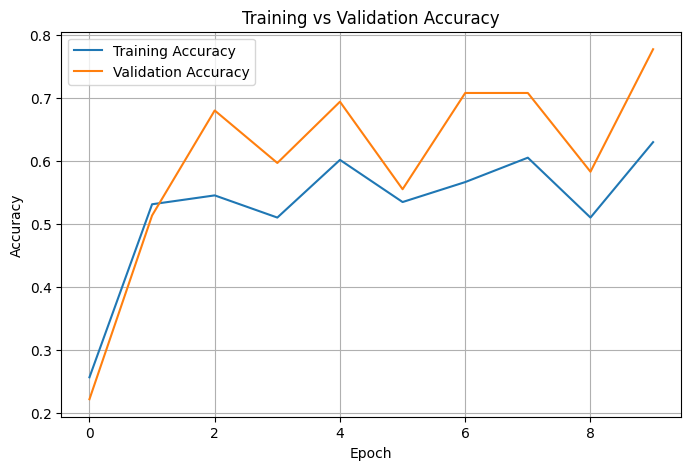

In [31]:
#plotting training accuracy
plt.figure(figsize=(8,5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

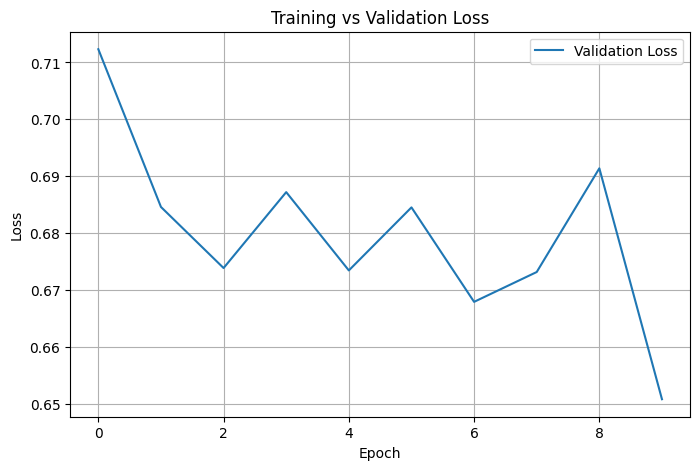

In [32]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

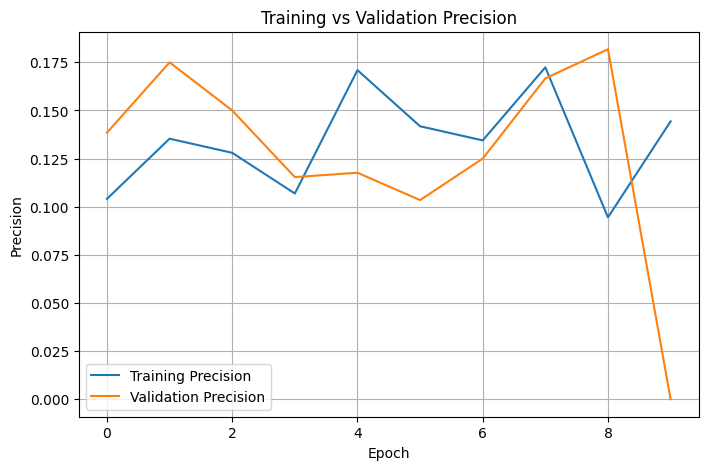

In [33]:
#plot precisison
plt.figure(figsize=(8,5))
plt.plot(
    history.history["precision"],
    label="Training Precision"
)
plt.plot(
    history.history["val_precision"],
    label="Validation Precision"
)
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision")
plt.legend()
plt.grid(True)
plt.show()

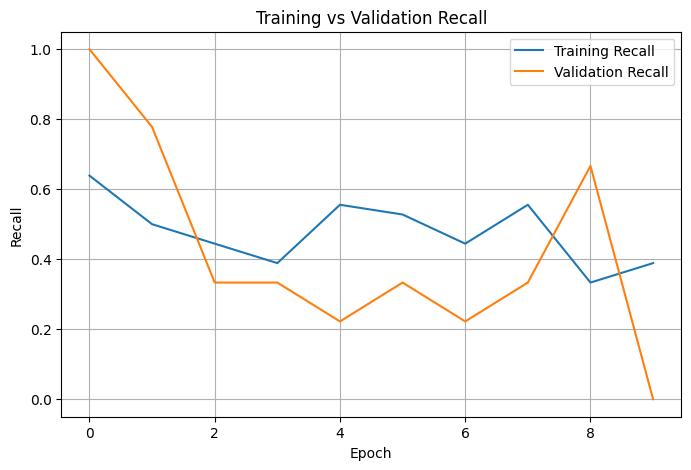

In [34]:
#plot recall
plt.figure(figsize=(8,5))
plt.plot(
    history.history["recall"],
    label="Training Recall"
)
plt.plot(
    history.history["val_recall"],
    label="Validation Recall"
)
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
#saving training history
np.save(
    os.path.join(
        MODEL_DIR,
        "simple_transformer_history.npy"
    ),
    history.history
)
print("Training History Saved")

Training History Saved


Evaluate the trained Simple Transformer using:

Accuracy
Precision
Recall
F1 Score
Confusion Matrix
Classification Report
ROC Curve
Prediction Distribution

In [38]:
# ============================================================
# Generate Predictions
# ============================================================
y_prob = model.predict(
    X_test_tokens,
    verbose=1
)
y_pred = (y_prob >= 0.5).astype(int)
print("Prediction Shape :", y_pred.shape)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 581ms/step
Prediction Shape : (90, 1)


In [39]:
# ============================================================
# Performance Metrics
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)
print("="*60)
print("Simple Transformer Performance")
print("="*60)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("="*60)

Simple Transformer Performance
Accuracy  : 0.8000
Precision : 0.1818
Recall    : 0.1818
F1 Score  : 0.1818


In [41]:
#classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Flood",
            "Flood"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Flood       0.89      0.89      0.89        79
       Flood       0.18      0.18      0.18        11

    accuracy                           0.80        90
   macro avg       0.53      0.53      0.53        90
weighted avg       0.80      0.80      0.80        90



In [42]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
print(cm)

[[70  9]
 [ 9  2]]


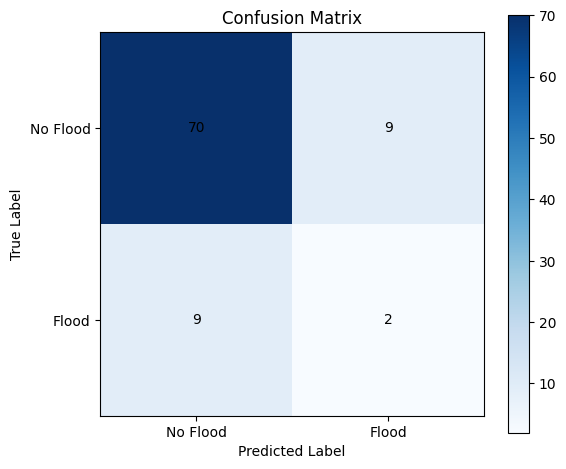

In [43]:
#plot
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
classes = ["No Flood", "Flood"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [44]:
#roc curve
from sklearn.metrics import roc_curve, auc

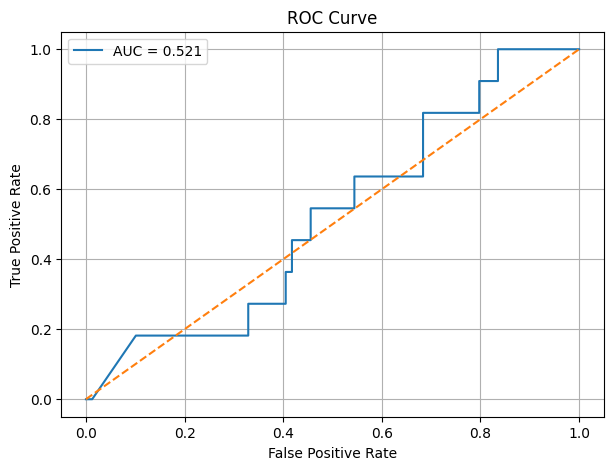

In [45]:
# ============================================================
# ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)
roc_auc = auc(
    fpr,
    tpr
)
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

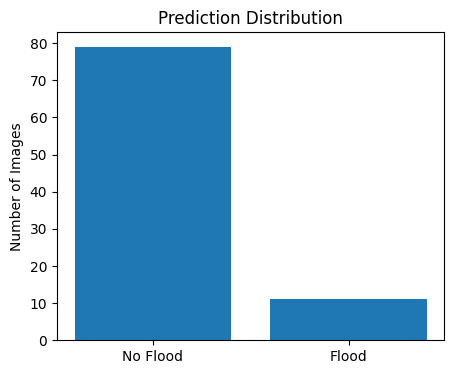

{np.int64(0): np.int64(79), np.int64(1): np.int64(11)}


In [46]:
# ============================================================
# Prediction Distribution
# ============================================================
unique, counts = np.unique(
    y_pred,
    return_counts=True
)
plt.figure(figsize=(5,4))
plt.bar(
    ["No Flood", "Flood"],
    counts
)
plt.title("Prediction Distribution")
plt.ylabel("Number of Images")
plt.show()
print(dict(zip(unique, counts)))

In [47]:
#save evaluation results
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}
print(results)

{'Accuracy': 0.8, 'Precision': 0.18181818181818182, 'Recall': 0.18181818181818182, 'F1 Score': 0.18181818181818182}


Visualize sample predictions made by the Simple Transformer on unseen SAR images.

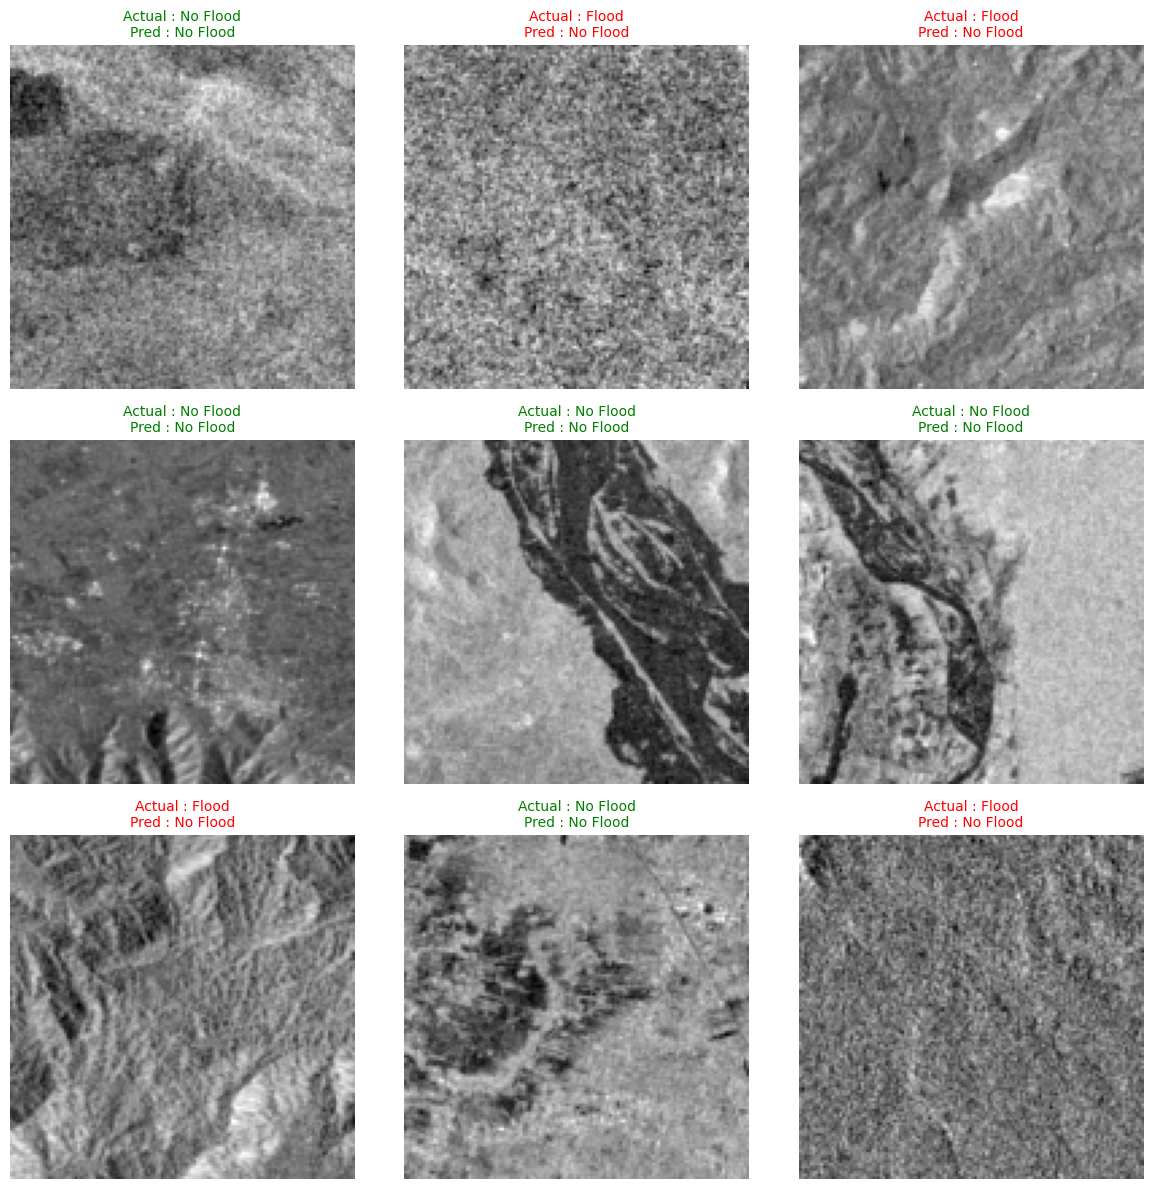

In [48]:
#visualize random predictions
import random
num_samples = 9
indices = random.sample(range(len(X_test)), num_samples)
plt.figure(figsize=(12,12))
for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    plt.imshow(
        X_test[idx].squeeze(),
        cmap="gray"
    )
    actual = "Flood" if y_test[idx] == 1 else "No Flood"
    predicted = "Flood" if y_pred[idx] == 1 else "No Flood"
    color = "green" if actual == predicted else "red"
    plt.title(
        f"Actual : {actual}\nPred : {predicted}",
        color=color,
        fontsize=10
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [49]:
#prediction probabilities
for i in range(10):
    print("="*50)
    print(f"Image {i+1}")
    print(f"Actual Label      : {y_test[i]}")
    print(f"Prediction Score  : {y_prob[i][0]:.4f}")
    print(f"Predicted Label   : {y_pred[i][0]}")

Image 1
Actual Label      : 0
Prediction Score  : 0.4833
Predicted Label   : 0
Image 2
Actual Label      : 0
Prediction Score  : 0.4319
Predicted Label   : 0
Image 3
Actual Label      : 0
Prediction Score  : 0.5368
Predicted Label   : 1
Image 4
Actual Label      : 0
Prediction Score  : 0.4351
Predicted Label   : 0
Image 5
Actual Label      : 0
Prediction Score  : 0.4932
Predicted Label   : 0
Image 6
Actual Label      : 0
Prediction Score  : 0.4441
Predicted Label   : 0
Image 7
Actual Label      : 1
Prediction Score  : 0.4759
Predicted Label   : 0
Image 8
Actual Label      : 0
Prediction Score  : 0.4760
Predicted Label   : 0
Image 9
Actual Label      : 0
Prediction Score  : 0.4917
Predicted Label   : 0
Image 10
Actual Label      : 0
Prediction Score  : 0.4504
Predicted Label   : 0


In [50]:
#correct vs incorrect predictions
correct = np.sum(y_pred.flatten() == y_test)
incorrect = len(y_test) - correct
print("="*50)
print("Correct Predictions :", correct)
print("Incorrect Predictions :", incorrect)
print()
print("Accuracy :", correct/len(y_test))

Correct Predictions : 72
Incorrect Predictions : 18

Accuracy : 0.8


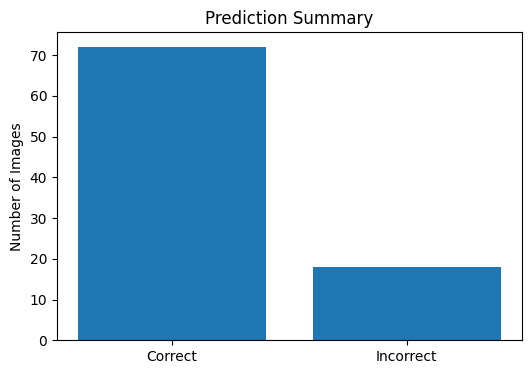

In [52]:
# ============================================================
# Prediction Summary
# ============================================================
labels = ["Correct","Incorrect"]
values = [correct, incorrect]
plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Prediction Summary")
plt.ylabel("Number of Images")
plt.show()

In [53]:
# ============================================================
# Save Results
# ============================================================
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}
np.save(
    os.path.join(
        RESULT_DIR,
        "simple_transformer_results.npy"
    ),
    results
)
print("Results Saved Successfully")

Results Saved Successfully


In [55]:
#final summary
print("="*70)
print("CNN + Simple Transformer Pipeline Completed")
print("="*70)
print()
print("Pipeline")
print()
print("SAR Images")
print("     ↓")
print("Median Filtering")
print("     ↓")
print("CNN Autoencoder")
print("     ↓")
print("Latent Features")
print("     ↓")
print("Simple Transformer")
print("     ↓")
print("Flood Prediction")
print()
print("="*70)
print("Notebook 7 Completed Successfully!")
print("="*70)

CNN + Simple Transformer Pipeline Completed

Pipeline

SAR Images
     ↓
Median Filtering
     ↓
CNN Autoencoder
     ↓
Latent Features
     ↓
Simple Transformer
     ↓
Flood Prediction

Notebook 7 Completed Successfully!
